# Eda Time Series

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle


## Definición del problema

>### Sistema de predicción de ventas
>Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

## Recopilación de datos

In [ ]:
df = pd.read_csv('../data/raw/sales.csv')
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


## Análisis Descriptivo

In [16]:
df.shape

(366, 2)

>El dataframe consta de 366 filas y 2 columnas, siendo la primera la fecha y la segunda las ventas

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


>No tenemos valores nulos en ninguna de las dos columnas y la fecha está en formato object y las ventas en formato numérico decimal de coma flotante

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sales,366.0,524.963968,275.089698,53.803211,290.186822,520.699468,763.289263,1000.482785


In [19]:
df.nunique()

date     366
sales    366
dtype: int64

## Limpieza de datos

### Eliminar duplicados

In [20]:
df.duplicated().sum()

np.int64(0)

>No hay valores duplicados

### Eliminar información irrelevante

>No hay información irrelevante ya que el conjunto de datos tiene solo dos columnas que son la fecha y las ventas

## Análisis de Variables

>Solo analizaré la variable sales ya que la otra solo indica las fechas y tenemos una entrada por dia

### Análisis de Variables Univariante

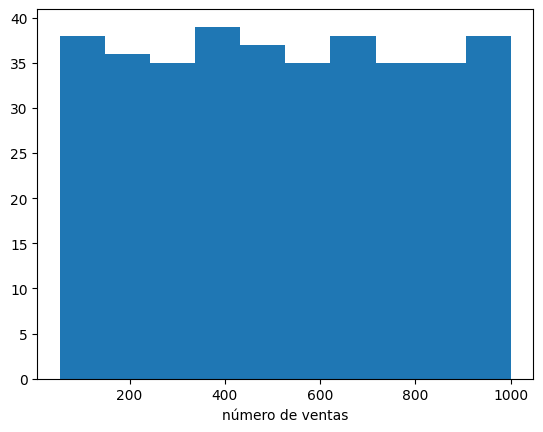

In [21]:
plt.hist(df['sales'], bins='auto')
plt.xlabel('número de ventas')

plt.show()


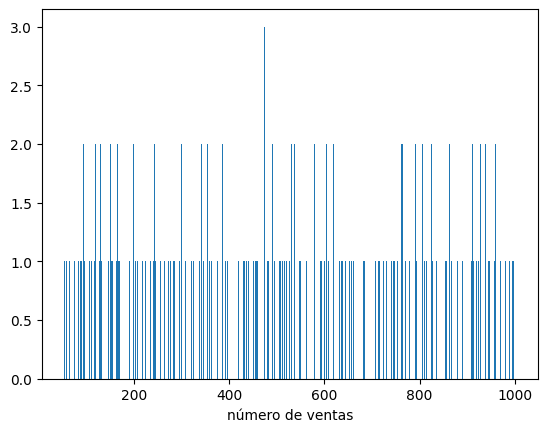

In [22]:
plt.hist(df['sales'], bins=1000)
plt.xlabel('número de ventas')

plt.show()


>Vemos que las cantidades de ventas estan repartidas de manera bastante equitativa. La gran mayoría de las cantidades de ventas ocurre aproximadamente la misma cantidad de dias (entre 0 y 3)

## Ingeniería de Características

### Outliers

>No trataremos outliers en este proyecto

### Faltantes

In [23]:
df.isnull().sum().sort_values(ascending=False)

date     0
sales    0
dtype: int64

>No hay valores nulos

### Inferencia de nuevas caracteristicas

>Más que buscar nuevas características trataremos la fecha de un object a un datetime y lo pondremos como índice.

In [24]:
df["date"] = pd.to_datetime(df.date)
df.set_index("date", inplace=True)
df

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633
...,...
2023-08-30 17:10:08.079328,989.600354
2023-08-31 17:10:08.079328,994.987326
2023-09-01 17:10:08.079328,995.814415


## Split

>No haremos un split clasico ya que el modelo es una serie temporal, haremos el split cortando la parte final del dataset (el 20% final que equivale a 73 dias)

In [25]:
Xy_train = df[:-73]
Xy_test = df[-73:]

## Scaling & Encoding

### Encoding

>En este proyecto no es necesario un encoding porque ya están tratados los datos

### Scaling

>En este proyecto no hace falta escalado ya que solo tenemos una variable numérica

## Guardado de datos procesados

In [ ]:
with open('../data/processed/time-series-Xy-train.pkl', 'wb') as file:
    pickle.dump(Xy_train, file)

with open('../data/processed/time-series-Xy-test.pkl', 'wb') as file:
    pickle.dump(Xy_test, file)  